In [1]:
import tensorflow as tf, numpy as np, matplotlib.pyplot as plt
from tensorflow.keras import layers, Model

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

In [3]:
class Encoder(Model):
    def __init__(self, latent):
        super().__init__()
        self.f = layers.Flatten()
        self.d1 = layers.Dense(256, activation='relu')
        self.d2 = layers.Dense(128, activation='relu')
        self.mu = layers.Dense(latent)
        self.logvar = layers.Dense(latent)
    def call(self, x):
        h = self.d2(self.d1(self.f(x)))
        mu = self.mu(h)
        lv = self.logvar(h)
        eps = tf.random.normal(tf.shape(mu))
        z = mu + tf.exp(0.5 * lv) * eps
        return z, mu, lv

In [4]:
class Decoder(Model):
    def __init__(self, latent):
        super().__init__()
        self.net = tf.keras.Sequential([
            layers.Input((latent,)),
            layers.Dense(128, activation='relu'),
            layers.Dense(256, activation='relu'),
            layers.Dense(784, activation='sigmoid'),
            layers.Reshape((28, 28, 1))
        ])
    def call(self, z): return self.net(z)

In [5]:
class VAE(Model):
    def __init__(self, latent):
        super().__init__()
        self.encoder = Encoder(latent)
        self.decoder = Decoder(latent)
        self.rt = tf.keras.metrics.Mean()
        self.kt = tf.keras.metrics.Mean()
        self.et = tf.keras.metrics.Mean()
    @property
    def metrics(self): return [self.rt, self.kt, self.et]
    def train_step(self, x):
        with tf.GradientTape() as tape:
            z, mu, lv = self.encoder(x)
            xr = self.decoder(z)
            rec = tf.reduce_mean(tf.reduce_sum(tf.keras.losses.binary_crossentropy(x, xr), axis=(1, 2)))
            kl = tf.reduce_mean(-0.5 * tf.reduce_sum(1 + lv - tf.square(mu) - tf.exp(lv), axis=1))
            loss = rec + kl
        g = tape.gradient(loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(g, self.trainable_weights))
        self.rt.update_state(rec); self.kt.update_state(kl); self.et.update_state(loss)
        return {"reconstruction": self.rt.result(), "kl": self.kt.result(), "elbo": self.et.result()}

In [6]:
latent_dims = [2, 8, 16]
vaes = {}

for latent in latent_dims:
    print("\nTraining VAE with latent dim:", latent)
    vae = VAE(latent)
    vae.compile(optimizer=tf.keras.optimizers.Adam(1e-3))
    vae.fit(x_train, epochs=10, batch_size=128, verbose=1)
    vaes[latent] = vae


Training VAE with latent dim: 2
Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - elbo: 193.2417 - kl: 5.6156 - reconstruction: 187.6262
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - elbo: 166.2065 - kl: 4.8820 - reconstruction: 161.3245
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - elbo: 160.7473 - kl: 5.2808 - reconstruction: 155.4665
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - elbo: 156.9585 - kl: 5.5861 - reconstruction: 151.3723
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - elbo: 154.3391 - kl: 5.7559 - reconstruction: 148.5832
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - elbo: 152.5367 - kl: 5.8853 - reconstruction: 146.6514
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - elbo: 150.9640 - kl: 5.9691 - reconstruction: 144.9949
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - elbo: 149.7175 - kl: 6.0363 - reconstruction: 143.6813
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - elbo: 148.8594 - kl: 6.1088 - reconstruct

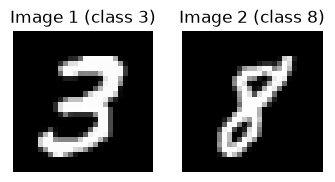

In [7]:
digit_a, digit_b = 3, 8
idx_a = np.where(y_train == digit_a)[0][0]
idx_b = np.where(y_train == digit_b)[0][0]

img1 = x_train[idx_a:idx_a + 1]
img2 = x_train[idx_b:idx_b + 1]

plt.figure(figsize=(4, 2))
plt.subplot(1, 2, 1); plt.imshow(img1[0].squeeze(), cmap='gray'); plt.axis('off'); plt.title(f"Image 1 (class {digit_a})")
plt.subplot(1, 2, 2); plt.imshow(img2[0].squeeze(), cmap='gray'); plt.axis('off'); plt.title(f"Image 2 (class {digit_b})")
plt.show()

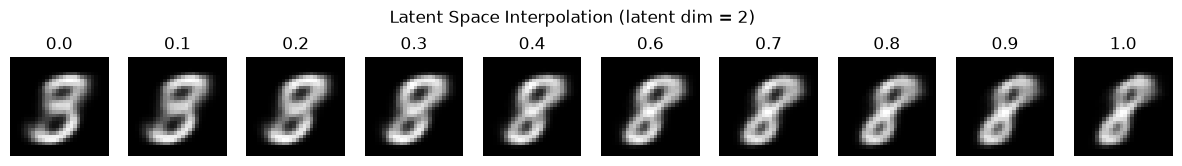

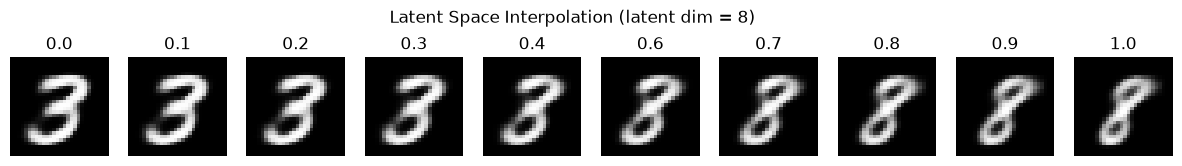

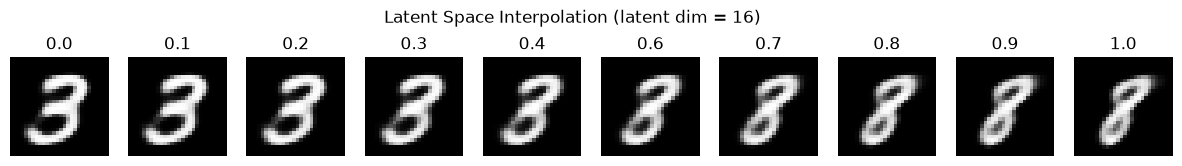

In [8]:
def interpolate_and_plot(vae, img1, img2, latent, n_steps=10):
    _, mu1, _ = vae.encoder.predict(img1, verbose=0)
    _, mu2, _ = vae.encoder.predict(img2, verbose=0)
    z1, z2 = mu1[0], mu2[0]

    alphas = np.linspace(0, 1, n_steps)
    interpolated_imgs = []
    for a in alphas:
        z = (1 - a) * z1 + a * z2
        img = vae.decoder.predict(z[None, :], verbose=0)[0]
        interpolated_imgs.append(img)

    plt.figure(figsize=(15, 2))
    plt.suptitle(f"Latent Space Interpolation (latent dim = {latent})")
    for i, (a, img) in enumerate(zip(alphas, interpolated_imgs)):
        plt.subplot(1, n_steps, i + 1)
        plt.imshow(img.squeeze(), cmap='gray')
        plt.axis('off')
        plt.title(f"{a:.1f}")
    plt.show()
    return interpolated_imgs

for latent in latent_dims:
    interpolate_and_plot(vaes[latent], img1, img2, latent)

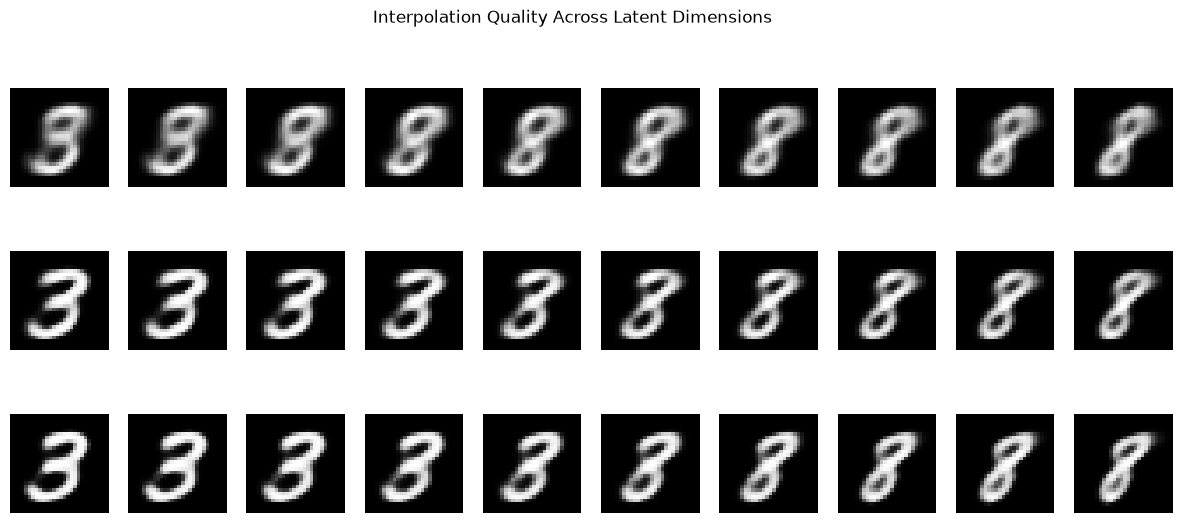

In [9]:
fig, axes = plt.subplots(len(latent_dims), 10, figsize=(15, 2 * len(latent_dims)))
for row, latent in enumerate(latent_dims):
    _, mu1, _ = vaes[latent].encoder.predict(img1, verbose=0)
    _, mu2, _ = vaes[latent].encoder.predict(img2, verbose=0)
    z1, z2 = mu1[0], mu2[0]
    alphas = np.linspace(0, 1, 10)
    for col, a in enumerate(alphas):
        z = (1 - a) * z1 + a * z2
        img = vaes[latent].decoder.predict(z[None, :], verbose=0)[0]
        axes[row, col].imshow(img.squeeze(), cmap='gray')
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(f"latent={latent}")
fig.suptitle("Interpolation Quality Across Latent Dimensions")
plt.show()

In [10]:
for latent in latent_dims:
    _, mu1, _ = vaes[latent].encoder.predict(img1, verbose=0)
    _, mu2, _ = vaes[latent].encoder.predict(img2, verbose=0)
    mid_z = 0.5 * (mu1[0] + mu2[0])
    mid_img = vaes[latent].decoder.predict(mid_z[None, :], verbose=0)[0]
    recon1 = vaes[latent].decoder.predict(mu1, verbose=0)[0]
    recon2 = vaes[latent].decoder.predict(mu2, verbose=0)[0]
    smoothness = np.mean((mid_img - 0.5 * (recon1 + recon2)) ** 2)
    print(f"latent={latent} midpoint-vs-average pixelwise difference:", smoothness)

latent=2 midpoint-vs-average pixelwise difference: 0.0047456166
latent=8 midpoint-vs-average pixelwise difference: 0.007108829
latent=16 midpoint-vs-average pixelwise difference: 0.008550844
